In [5]:
import sys, os
sys.path.append(os.path.dirname(os.getcwd()))
import pandas as pd 
import matplotlib.pyplot as plt
import os

from plot_results import format_experiment_data, load_statistics


In [6]:
# Where the results are stored
results_data_root = "../data/results"

# The dataset name
dataset_name = "nqopen_small"

# Where to save the produced plots
output_dir = "../data/plots"
os.makedirs(output_dir, exist_ok=True)

In [7]:
# Path to the root of the benchmark results
root_results_path = f'{results_data_root}/{dataset_name}/question_bias'

assert os.path.exists(root_results_path), f"The path {root_results_path} does not exist. Please make sure that you set correctly the data_root and dataset_name variables."

# Check if a data/ folder already exists
if not os.path.exists(f"{results_data_root}/{dataset_name}/data"):
    
    # If the data folder does not exis, the benchmark results are still in raw format and we should process them before the analysis
    format_experiment_data(root_results_path)

# Load all statistics in a single dataframe
df_results_all = load_statistics(root_results_path)

# Convert 'Ben','Mal','Ben&mal','Hallucination','Avg # mal docs in prompt' to numeric
df_results_all['Ben'] = pd.to_numeric(df_results_all['Ben'])
df_results_all['Mal'] = pd.to_numeric(df_results_all['Mal'])
df_results_all['Ben&mal'] = pd.to_numeric(df_results_all['Ben&mal'])
df_results_all['Hallucination'] = pd.to_numeric(df_results_all['Hallucination'])
df_results_all['Avg # mal docs in prompt'] = pd.to_numeric(df_results_all['Avg # mal docs in prompt'])

# Set Injection strategy to null if nan
df_results_all.loc[df_results_all['Injection strategy']=='nan','Injection strategy'] = ''

The following block prints a table displaying the performance of the default pipeline normally and under attack.

The following block prints a graph that shows the performance of the base RAG pipeline when using original / mutated queries. 

/tmp/ipykernel_3719332/3713152644.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ben.rename(columns={'Ben':'Score'}, inplace=True)
/tmp/ipykernel_3719332/3713152644.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ben['Metric'] = 'Ben'
/tmp/ipykernel_3719332/3713152644.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versu

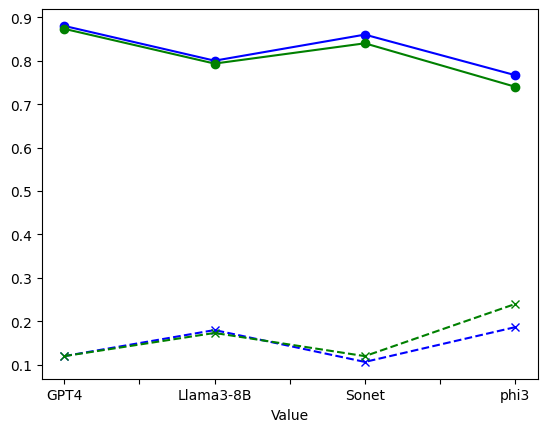

In [8]:
df_ben = df_results_all[['Parameter','Value','Ben']]
df_ben.rename(columns={'Ben':'Score'}, inplace=True)
df_ben['Metric'] = 'Ben'
df_ben[['style','marker']] = '-','o'

df_mal = df_results_all[['Parameter','Value','Hallucination']]
df_mal.rename(columns={'Hallucination':'Score'}, inplace=True)
df_mal['Metric'] = 'Hallucination'
df_mal[['style','marker']] = pd.DataFrame([['--','x']]*len(df_mal))

df = pd.concat([df_ben,df_mal])
df['color'] = df['Parameter'].apply(lambda x: 'green' if 'Original queries' in x else 'blue')

# order by value
df = df.sort_values(by='Value')

df = df.groupby(['Parameter','Metric'])

# Plot a line for each parameter
fig, ax = plt.subplots()
for i, group in df:
    group.plot(x='Value', y='Score', ax=ax, label=i, style=group['style'].iloc[0], marker=group['marker'].iloc[0], color=group['color'].iloc[0],legend=False)
fig.show()
fig.savefig(f"{output_dir}/{dataset_name}_bias.png")